In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

players = pd.read_csv(
    r"../data/Squad_PlayerStats__stats_standard.csv"
)

players.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0,0,7,0,0.00,0.14,0.14,0.00,0.14,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0,0,4,0,0.06,0.06,0.13,0.06,0.13,Matches
4,5,Simon Adingra,ci CIV,MF,Brighton,22.0,2002.0,29,12,1097,...,0,0,0,0,0.16,0.16,0.33,0.16,0.33,Matches


In [2]:
players.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born',
       'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min',
       'Playing Time_90s', 'Performance_Gls', 'Performance_Ast',
       'Performance_G+A', 'Performance_G-PK', 'Performance_PK',
       'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR',
       'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A',
       'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'Matches'],
      dtype='str')

In [3]:
players = players.rename(columns={
    "Player": "player",
    "Squad": "team",
    "Playing Time_Min": "minutes",
    "Performance_Gls": "goals",
    "Performance_Ast": "assists",
    "Performance_G+A": "goal_contributions"
})

players["team"] = players["team"].str.strip()

players.head()

,Rk,player,Nation,Pos,team,Age,Born,Playing Time_MP,Playing Time_Starts,minutes,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0,0,7,0,0.00,0.14,0.14,0.00,0.14,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0,0,4,0,0.06,0.06,0.13,0.06,0.13,Matches
4,5,Simon Adingra,ci CIV,MF,Brighton,22.0,2002.0,29,12,1097,...,0,0,0,0,0.16,0.16,0.33,0.16,0.33,Matches


In [4]:
players["goals_per90"] = (
    players["goals"] / players["minutes"] * 90
)

In [5]:
top_scorers = players.sort_values(
    by="goals",
    ascending=False
)

top_scorers[[
    "player",
    "team",
    "goals"
]].head(10)

,player,team,goals
448,Mohamed Salah,Liverpool,29
252,Alexander Isak,Newcastle United,23
224,Erling Haaland,Manchester City,22
340,Bryan Mbeumo,Brentford,20
563,Chris Wood,Nottingham Forest,20
562,Yoane Wissa,Brentford,19
547,Ollie Watkins,Aston Villa,16
115,Matheus Cunha,Wolves,15
407,Cole Palmer,Chelsea,15
493,Jørgen Strand Larsen,Wolves,14


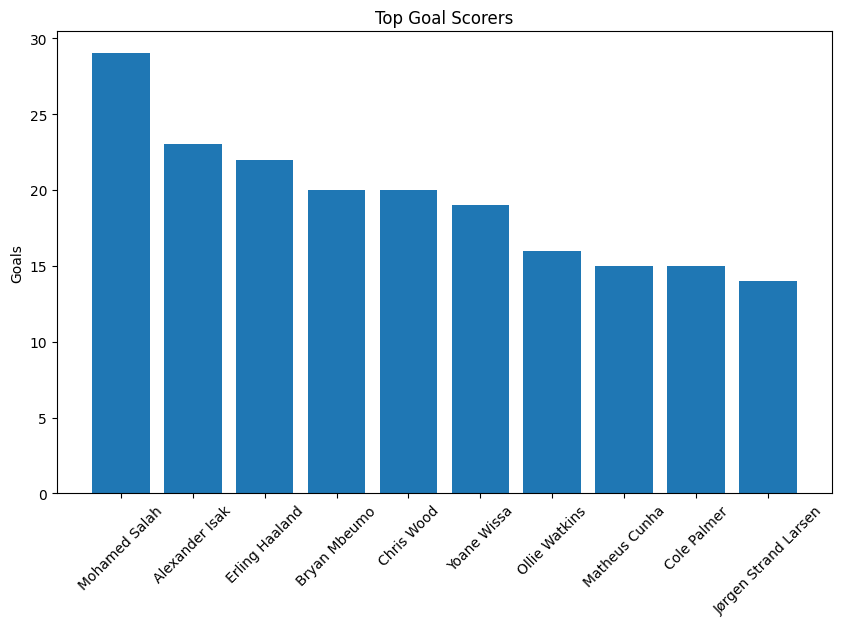

In [6]:
plt.figure(figsize=(10,6))

plt.bar(
    top_scorers["player"].head(10),
    top_scorers["goals"].head(10)
)

plt.xticks(rotation=45)
plt.ylabel("Goals")
plt.title("Top Goal Scorers")

plt.show()

In [7]:
top_contributors = players.sort_values(
    by="goal_contributions",
    ascending=False
)

top_contributors[[
    "player",
    "team",
    "goal_contributions"
]].head(10)

,player,team,goal_contributions
448,Mohamed Salah,Liverpool,47
252,Alexander Isak,Newcastle United,29
340,Bryan Mbeumo,Brentford,27
224,Erling Haaland,Manchester City,25
547,Ollie Watkins,Aston Villa,24
407,Cole Palmer,Chelsea,23
562,Yoane Wissa,Brentford,23
563,Chris Wood,Nottingham Forest,23
115,Matheus Cunha,Wolves,21
64,Jarrod Bowen,West Ham United,21


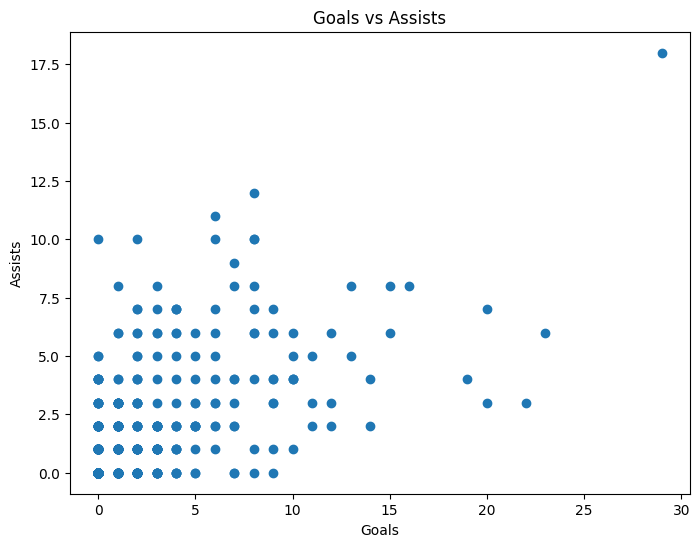

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    players["goals"],
    players["assists"]
)

plt.xlabel("Goals")
plt.ylabel("Assists")
plt.title("Goals vs Assists")

plt.show()

In [9]:
impact_players = players[players["minutes"] > 900]

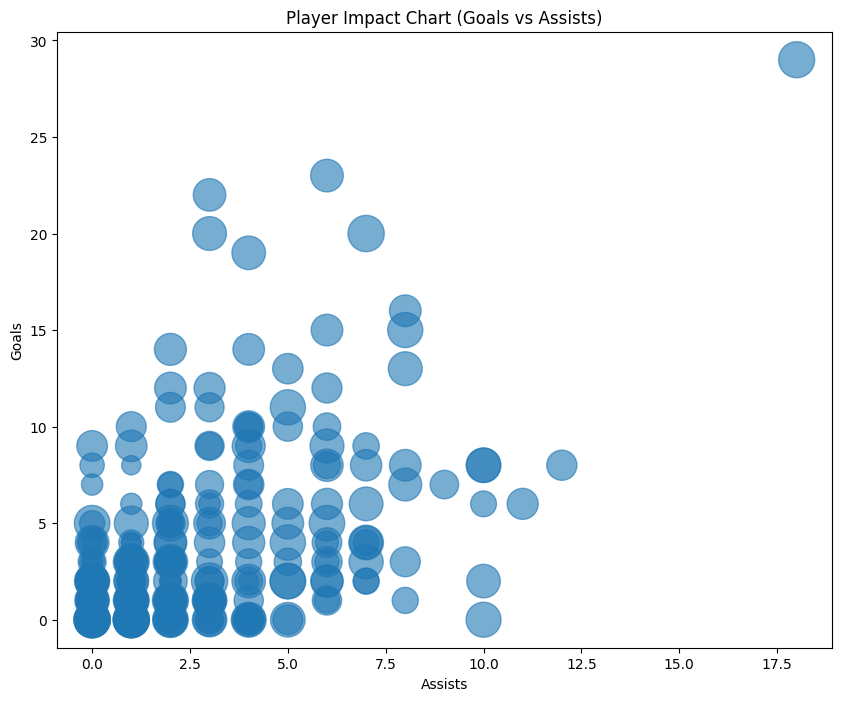

In [10]:
plt.figure(figsize=(10,8))

plt.scatter(
    impact_players["assists"],
    impact_players["goals"],
    s=impact_players["minutes"]/5,
    alpha=0.6
)

plt.xlabel("Assists")
plt.ylabel("Goals")
plt.title("Player Impact Chart (Goals vs Assists)")

plt.show()

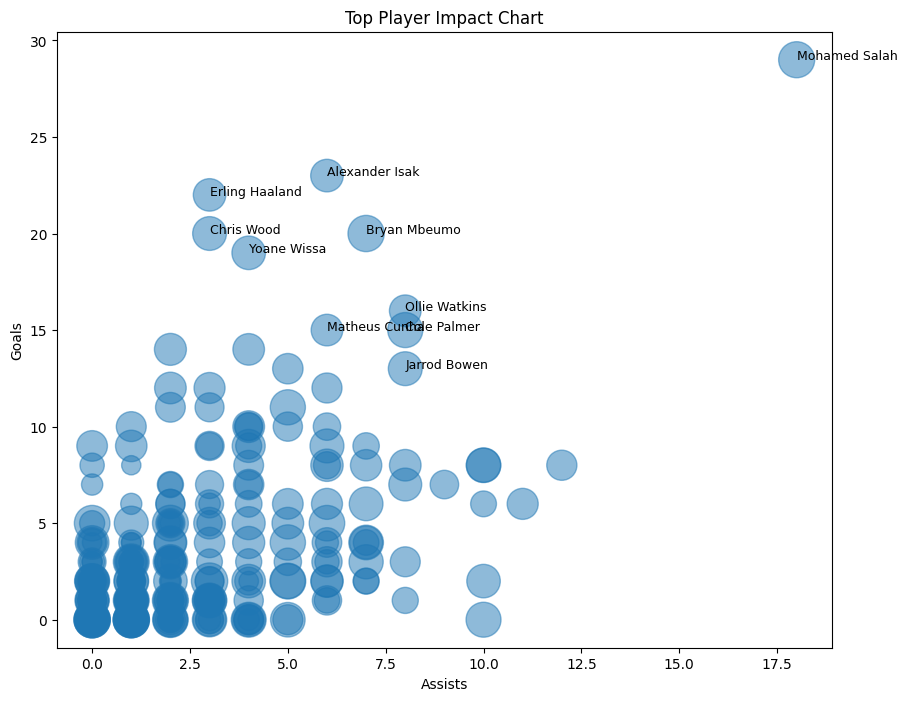

In [11]:
top_players = impact_players.sort_values(
    by="goal_contributions",
    ascending=False
).head(10)

plt.figure(figsize=(10,8))

plt.scatter(
    impact_players["assists"],
    impact_players["goals"],
    s=impact_players["minutes"]/5,
    alpha=0.5
)

for i in range(len(top_players)):
    plt.text(
        top_players["assists"].iloc[i],
        top_players["goals"].iloc[i],
        top_players["player"].iloc[i],
        fontsize=9
    )

plt.xlabel("Assists")
plt.ylabel("Goals")
plt.title("Top Player Impact Chart")

plt.show()